##IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
import warnings

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
    VotingRegressor
)

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

# Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

##LOAD DATASET

In [2]:
print("=" * 60)
print("LOADING DATASET")
print("=" * 60)

df = pd.read_csv("/content/household_energy_consumption.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

LOADING DATASET

First 5 Rows:
  Household_ID        Date  Energy_Consumption_kWh  Household_Size  \
0       H00001  2025-04-01                     8.4               4   
1       H00001  2025-04-02                     7.9               4   
2       H00001  2025-04-03                     9.2               4   
3       H00001  2025-04-04                     7.9               4   
4       H00001  2025-04-05                     9.6               4   

   Avg_Temperature_C Has_AC  Peak_Hours_Usage_kWh  
0               17.8     No                   3.2  
1               17.3     No                   2.8  
2               18.6     No                   3.0  
3               18.2     No                   2.7  
4               11.9     No                   3.2  

Dataset Shape:
(90000, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  ----

##EXPLORATORY DATA ANALYSIS (EDA)


EXPLORATORY DATA ANALYSIS
       Energy_Consumption_kWh  Household_Size  Avg_Temperature_C  \
count            90000.000000    90000.000000       90000.000000   
mean                10.571988        3.487811          17.505802   
std                  5.519494        1.709761           2.491621   
min                  0.500000        1.000000          10.000000   
25%                  6.000000        2.000000          15.800000   
50%                 10.400000        3.000000          17.500000   
75%                 14.800000        5.000000          19.200000   
max                 20.000000        6.000000          25.000000   

       Peak_Hours_Usage_kWh  
count          90000.000000  
mean               4.319557  
std                2.531432  
min                0.200000  
25%                2.300000  
50%                4.000000  
75%                6.000000  
max               10.000000  


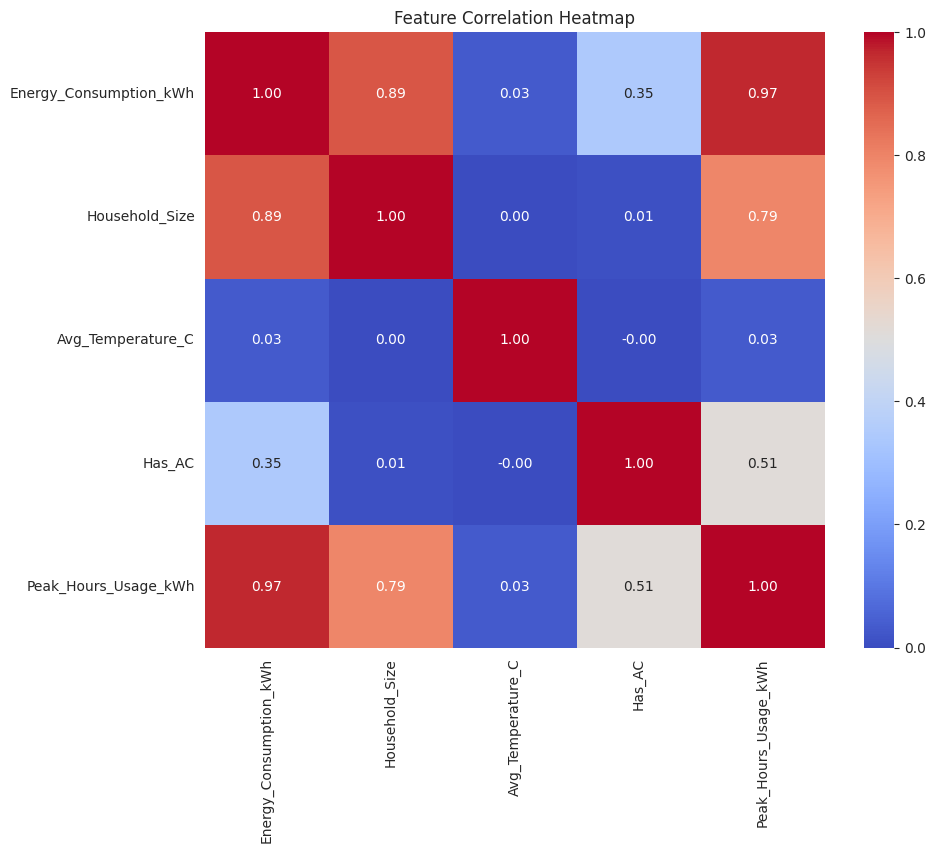

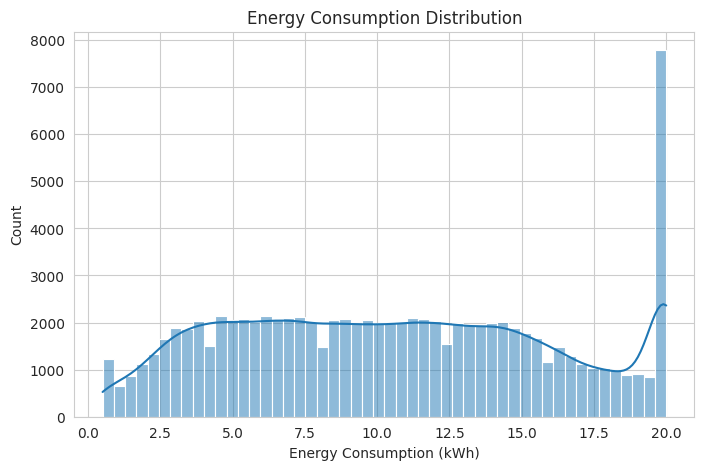


OUTLIER DETECTION


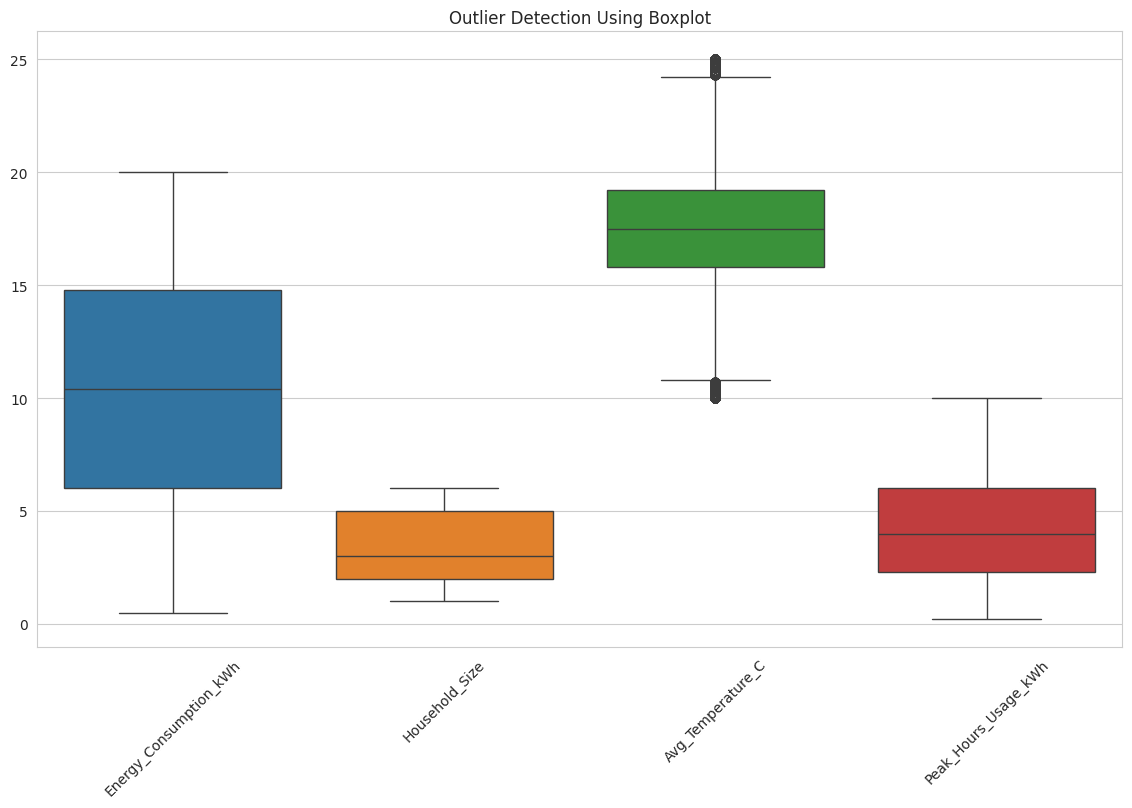


Total Outliers per Feature:
Energy_Consumption_kWh      0
Household_Size              0
Avg_Temperature_C         595
Peak_Hours_Usage_kWh        0
dtype: int64


In [3]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Statistical Summary
print(df.describe())

# Correlation Heatmap
plt.figure(figsize=(10, 8))

temp_df = df.copy()

temp_df['Has_AC'] = temp_df['Has_AC'].map({
    'Yes': 1,
    'No': 0
})

temp_df['Date'] = pd.to_datetime(temp_df['Date'])

corr = temp_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution Plot
plt.figure(figsize=(8, 5))
sns.histplot(df['Energy_Consumption_kWh'], kde=True)
plt.title("Energy Consumption Distribution")
plt.xlabel("Energy Consumption (kWh)")
plt.show()

# Outlier Detection
print("\n" + "=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14, 8))

sns.boxplot(data=df[numeric_cols])

plt.title("Outlier Detection Using Boxplot")
plt.xticks(rotation=45)

plt.show()

# IQR Method
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (df[numeric_cols] < (Q1 - 1.5 * IQR)) |
    (df[numeric_cols] > (Q3 + 1.5 * IQR))
)

print("\nTotal Outliers per Feature:")
print(outliers.sum())

##DATA PREPROCESSING & FEATURE ENGINEERING

In [4]:
print("\n" + "=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

df_processed = df.copy()

# Encode categorical feature
df_processed['Has_AC'] = df_processed['Has_AC'].map({
    'Yes': 1,
    'No': 0
})

# Convert Date
df_processed['Date'] = pd.to_datetime(df_processed['Date'])

# Feature Engineering
df_processed['Day_of_Week'] = df_processed['Date'].dt.dayofweek
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day

# Weekend Feature
df_processed['Is_Weekend'] = df_processed['Day_of_Week'].apply(
    lambda x: 1 if x >= 5 else 0
)

# Season Feature
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

df_processed['Season'] = df_processed['Month'].apply(get_season)

# Temperature Category
df_processed['Temp_Category'] = pd.cut(
    df_processed['Avg_Temperature_C'],
    bins=[-np.inf, 20, 30, np.inf],
    labels=[0,1,2]
).astype(int)

# Usage Ratio Feature
df_processed['Usage_Per_Person'] = (
    df_processed['Peak_Hours_Usage_kWh'] /
    df_processed['Household_Size']
)

# Display preprocessing results
print("\nProcessed Dataset Preview:")
print(df_processed.head())

print("\nDataset Shape:")
print(df_processed.shape)

print("\nMissing Values After Preprocessing:")
print(df_processed.isnull().sum())

print("\nFeature Columns:")
print(df_processed.columns.tolist())


DATA PREPROCESSING

Processed Dataset Preview:
  Household_ID       Date  Energy_Consumption_kWh  Household_Size  \
0       H00001 2025-04-01                     8.4               4   
1       H00001 2025-04-02                     7.9               4   
2       H00001 2025-04-03                     9.2               4   
3       H00001 2025-04-04                     7.9               4   
4       H00001 2025-04-05                     9.6               4   

   Avg_Temperature_C  Has_AC  Peak_Hours_Usage_kWh  Day_of_Week  Month  Day  \
0               17.8       0                   3.2            1      4    1   
1               17.3       0                   2.8            2      4    2   
2               18.6       0                   3.0            3      4    3   
3               18.2       0                   2.7            4      4    4   
4               11.9       0                   3.2            5      4    5   

   Is_Weekend  Season  Temp_Category  Usage_Per_Person  
0    

##FEATURE & TARGET SELECTION

In [5]:
X = df_processed.drop(columns=[
    'Household_ID',
    'Date',
    'Energy_Consumption_kWh'
])

y = df_processed['Energy_Consumption_kWh']

print("\nFeatures Used:")
print(X.columns.tolist())


Features Used:
['Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh', 'Day_of_Week', 'Month', 'Day', 'Is_Weekend', 'Season', 'Temp_Category', 'Usage_Per_Person']


##TRAIN TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining Size : {X_train.shape}")
print(f"Testing Size  : {X_test.shape}")


Training Size : (72000, 11)
Testing Size  : (18000, 11)


##FEATURE SCALING

In [7]:
print("\n" + "=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

print("\nFeature scaling completed successfully!")

print("\nScaled Training Data Preview:")
print(X_train_scaled.head())


FEATURE SCALING

Feature scaling completed successfully!

Scaled Training Data Preview:
   Household_Size  Avg_Temperature_C    Has_AC  Peak_Hours_Usage_kWh  \
0        0.883746          -0.241461  1.011764              2.005694   
1       -0.872267          -0.081098 -0.988373             -1.311617   
2       -1.457605          -0.081098  1.011764             -1.035174   
3        0.298409           0.440081 -0.988373             -0.719240   
4        0.883746           0.239627  1.011764              1.689759   

   Day_of_Week  Month       Day  Is_Weekend  Season  Temp_Category  \
0    -0.001286    0.0 -0.500076   -0.632210     0.0      -0.425311   
1    -0.501930    0.0 -1.000799   -0.632210     0.0      -0.425311   
2     0.499357    0.0  0.000647   -0.632210     0.0      -0.425311   
3     0.499357    0.0  0.000647   -0.632210     0.0      -0.425311   
4     1.000000    0.0  0.501370    1.581754     0.0      -0.425311   

   Usage_Per_Person  
0          1.231799  
1         -1.

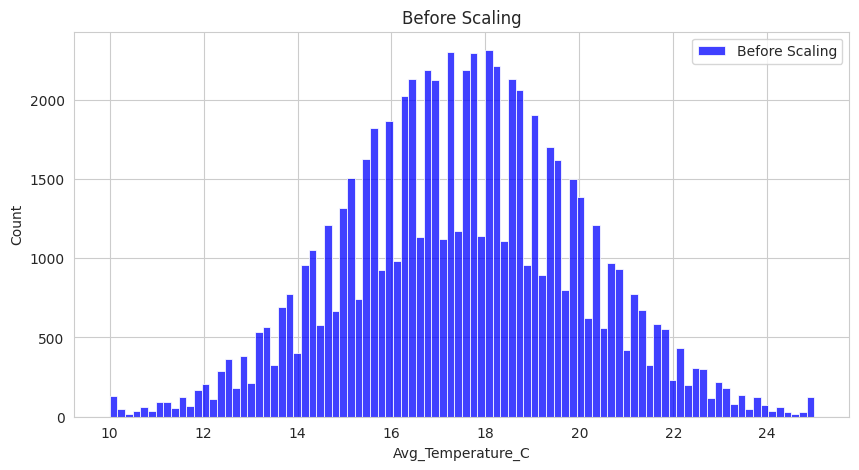

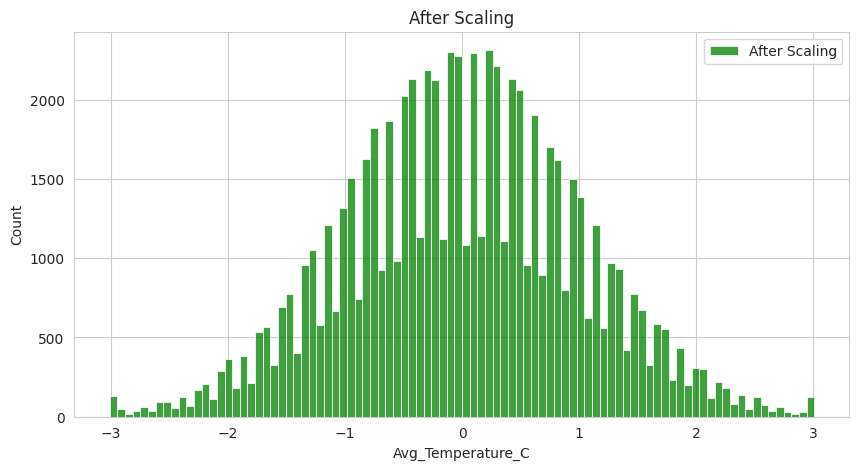

In [8]:
# Before Scaling
plt.figure(figsize=(10,5))

sns.histplot(
    X_train['Avg_Temperature_C'],
    color='blue',
    label='Before Scaling'
)

plt.title("Before Scaling")
plt.legend()

plt.show()

# After Scaling
plt.figure(figsize=(10,5))

sns.histplot(
    X_train_scaled['Avg_Temperature_C'],
    color='green',
    label='After Scaling'
)

plt.title("After Scaling")
plt.legend()

plt.show()

##FEATURE SELECTION USING XGBOOST


FEATURE SELECTION

Feature Importance:
                 Feature  Importance
3   Peak_Hours_Usage_kWh    0.844898
0         Household_Size    0.117964
2                 Has_AC    0.035144
10      Usage_Per_Person    0.000563
1      Avg_Temperature_C    0.000529
6                    Day    0.000474
4            Day_of_Week    0.000429
5                  Month    0.000000
7             Is_Weekend    0.000000
8                 Season    0.000000
9          Temp_Category    0.000000


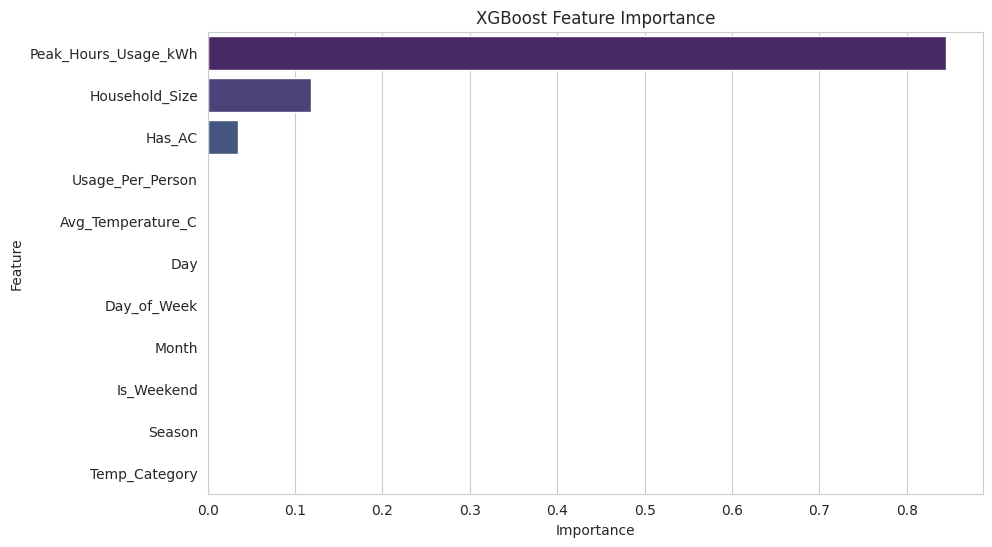


Selected Features:
['Peak_Hours_Usage_kWh', 'Household_Size']


In [9]:
print("\n" + "=" * 60)
print("FEATURE SELECTION")
print("=" * 60)

xgb_fs = XGBRegressor(
    n_estimators=200,
    random_state=42
)

xgb_fs.fit(X_train_scaled, y_train)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_fs.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("XGBoost Feature Importance")
plt.show()

# Select Top Features
selected_features = importance_df[
    importance_df['Importance'] > 0.05
]['Feature'].tolist()

print("\nSelected Features:")
print(selected_features)

X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

##HYPERPARAMETER TUNING

In [10]:
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_base = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_params,
    n_iter=10,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_selected, y_train)

best_xgb = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)


HYPERPARAMETER TUNING
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}


##MODELING

In [11]:
print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=[
        ('rf', rf_model),
        ('xgb', best_xgb),
        ('gb', gb_model)
    ],
    final_estimator=LinearRegression()
)

# Voting Regressor
voting_model = VotingRegressor(
    estimators=[
        ('rf', rf_model),
        ('xgb', best_xgb),
        ('gb', gb_model)
    ]
)

# REGISTER ALL MODELS
models = {
    'Random Forest': rf_model,
    'XGBoost': best_xgb,
    'Gradient Boosting': gb_model,
    'Stacking Regressor': stacking_model,
    'Voting Regressor': voting_model
}

# TRAINING PROCESS
for name, model in models.items():

    print(f"\nTraining {name}...")

    start_time = time.time()

    model.fit(X_train_selected, y_train)

    end_time = time.time()

    print(f"{name} completed successfully!")
    print(f"Training Time: {end_time - start_time:.4f} seconds")


MODEL TRAINING

Training Random Forest...
Random Forest completed successfully!
Training Time: 4.3156 seconds

Training XGBoost...
XGBoost completed successfully!
Training Time: 3.5913 seconds

Training Gradient Boosting...
Gradient Boosting completed successfully!
Training Time: 4.3415 seconds

Training Stacking Regressor...
Stacking Regressor completed successfully!
Training Time: 57.6879 seconds

Training Voting Regressor...
Voting Regressor completed successfully!
Training Time: 10.8280 seconds


##CROSS VALIDATION & EVALUATION

In [12]:
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

results = []

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    print(f"\nTraining {name}...")

    start_time = time.time()

    model.fit(X_train_selected, y_train)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_selected)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Cross Validation R2
    cv_score = cross_val_score(
        model,
        X_train_selected,
        y_train,
        cv=kf,
        scoring='r2'
    ).mean()

    # Cross Validation RMSE
    cv_rmse = np.abs(
        cross_val_score(
            model,
            X_train_selected,
            y_train,
            cv=kf,
            scoring='neg_root_mean_squared_error'
        ).mean()
    )

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'MAPE': round(mape, 4),
        'CV_R2': round(cv_score, 4),
        'CV_RMSE': round(cv_rmse, 4),
        'Training_Time': round(training_time, 4)
    })

results_df = pd.DataFrame(results)

print("\nFinal Results:")
print(results_df)


MODEL EVALUATION

Training Random Forest...

Training XGBoost...

Training Gradient Boosting...

Training Stacking Regressor...

Training Voting Regressor...

Final Results:
                Model     MAE    RMSE      R2    MAPE   CV_R2  CV_RMSE  \
0       Random Forest  0.5108  0.6726  0.9851  0.0607  0.9849   0.6776   
1             XGBoost  0.5108  0.6725  0.9852  0.0607  0.9849   0.6774   
2   Gradient Boosting  0.5126  0.6766  0.9850  0.0610  0.9848   0.6804   
3  Stacking Regressor  0.5106  0.6726  0.9851  0.0607  0.9849   0.6773   
4    Voting Regressor  0.5107  0.6728  0.9851  0.0607  0.9849   0.6774   

   Training_Time  
0         3.9855  
1         1.8559  
2         4.1136  
3        55.5320  
4         9.9169  


##BEST MODEL ANALYSIS

In [13]:
best_model_name = results_df.sort_values(
    by='R2',
    ascending=False
).iloc[0]['Model']

print(f"\nBest Model: {best_model_name}")

best_model = models[best_model_name]


Best Model: XGBoost


##ACTUAL VS PREDICTED VISUALIZATION

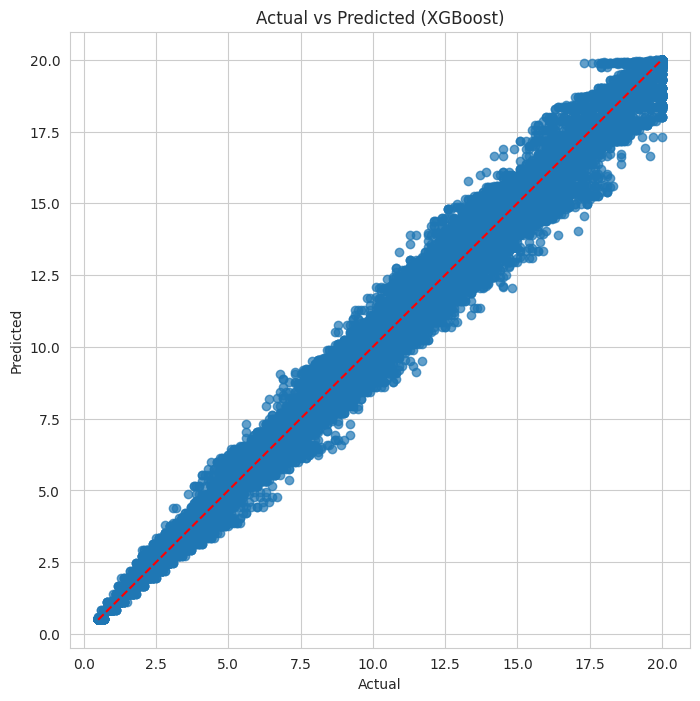

In [14]:
y_pred_best = best_model.predict(X_test_selected)

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")

plt.show()

##RESIDUAL ANALYSIS

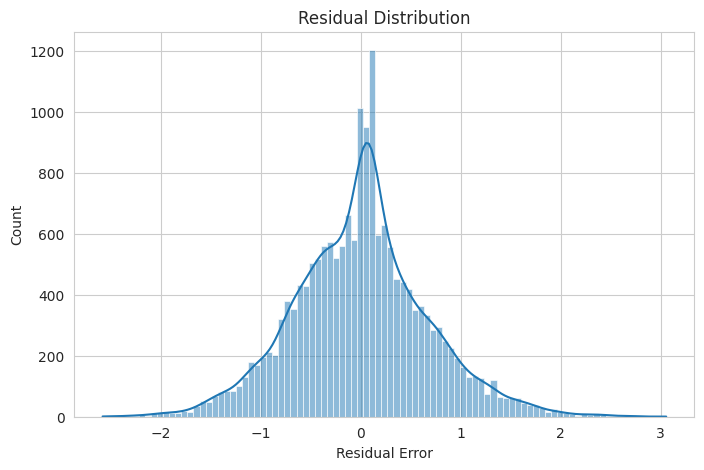

In [15]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residual Error")

plt.show()

##SHAP EXPLAINABLE AI


Generating SHAP analysis for XGBoost...


100%|===================| 17976/18000 [03:04<00:00]       


Displaying SHAP Summary Plot...


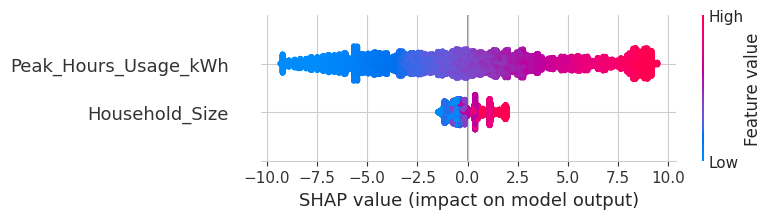


Displaying SHAP Feature Importance Plot...


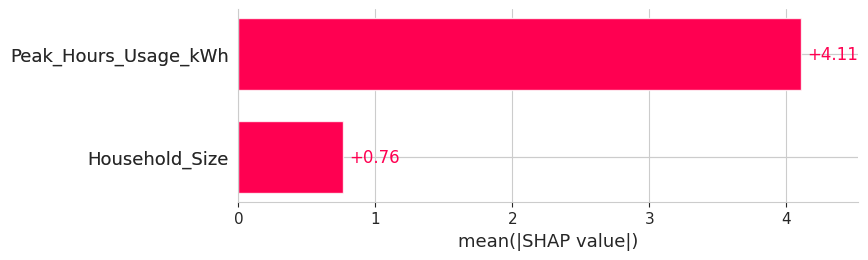


Top Important Features Based on SHAP:
                Feature  Mean_SHAP_Value
0  Peak_Hours_Usage_kWh         4.105257
1        Household_Size         0.761024


In [16]:
# SHAP only supports tree-based models safely
if best_model_name in [
    'Random Forest',
    'XGBoost',
    'Gradient Boosting'
]:

    print(f"\nGenerating SHAP analysis for {best_model_name}...")

    # Create SHAP Explainer
    explainer = shap.Explainer(
        best_model,
        X_train_selected
    )

    # Calculate SHAP values
    shap_values = explainer(X_test_selected)

    # =====================================================
    # SHAP SUMMARY PLOT
    # =====================================================

    print("\nDisplaying SHAP Summary Plot...")

    shap.summary_plot(
        shap_values,
        X_test_selected
    )

    # =====================================================
    # SHAP BAR PLOT
    # =====================================================

    print("\nDisplaying SHAP Feature Importance Plot...")

    shap.plots.bar(shap_values)

    # =====================================================
    # TOP IMPORTANT FEATURES BASED ON SHAP
    # =====================================================

    print("\nTop Important Features Based on SHAP:")

    feature_importance = pd.DataFrame({
        'Feature': X_train_selected.columns,
        'Mean_SHAP_Value': np.abs(shap_values.values).mean(axis=0)
    })

    feature_importance = feature_importance.sort_values(
        by='Mean_SHAP_Value',
        ascending=False
    )

    print(feature_importance.head(5))

else:

    print(
        f"\nSHAP analysis skipped because "
        f"{best_model_name} is not fully supported by SHAP."
    )

##FEATURE IMPORTANCE COMPARISON

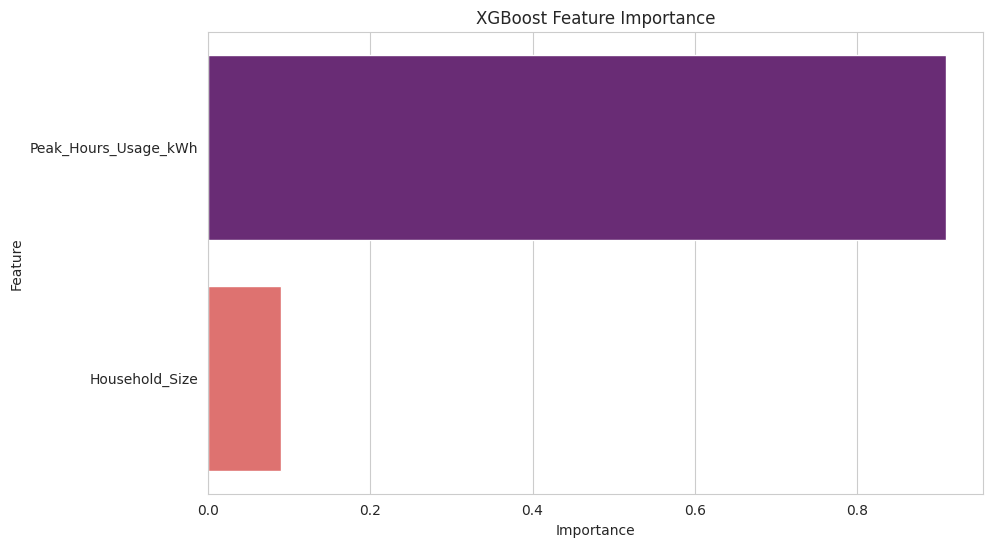

In [17]:
if hasattr(best_model, 'feature_importances_'):

    importance = pd.DataFrame({
        'Feature': X_train_selected.columns,
        'Importance': best_model.feature_importances_
    })

    importance = importance.sort_values(
        by='Importance',
        ascending=False
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=importance,
        x='Importance',
        y='Feature',
        palette='magma'
    )

    plt.title(f"{best_model_name} Feature Importance")

    plt.show()

##PREDICTION SIMULATION

In [18]:
print("\n" + "=" * 60)
print("NEW PREDICTION SIMULATION")
print("=" * 60)

# New Input Data
new_data = pd.DataFrame({
    'Household_Size': [3],
    'Avg_Temperature_C': [28],
    'Has_AC': [1],
    'Peak_Hours_Usage_kWh': [5],
    'Day_of_Week': [6],
    'Month': [7],
    'Day': [15],
    'Is_Weekend': [1],
    'Season': [2],
    'Temp_Category': [1],
    'Usage_Per_Person': [1.67]
})

# Scaling
new_data_scaled = scaler.transform(new_data)

# Convert back to DataFrame
new_data_scaled = pd.DataFrame(
    new_data_scaled,
    columns=new_data.columns
)

# Select features
new_data_scaled = new_data_scaled[selected_features]

# Prediction
prediction = best_model.predict(new_data_scaled)[0]

print("\nInput Data:")
print(new_data)

print(f"\nPredicted Energy Consumption: {prediction:.2f} kWh")


NEW PREDICTION SIMULATION

Input Data:
   Household_Size  Avg_Temperature_C  Has_AC  Peak_Hours_Usage_kWh  \
0               3                 28       1                     5   

   Day_of_Week  Month  Day  Is_Weekend  Season  Temp_Category  \
0            6      7   15           1       2              1   

   Usage_Per_Person  
0              1.67  

Predicted Energy Consumption: 11.13 kWh


##SAVE RESULTS

In [19]:
results_df.to_csv(
    "model_experiment_results.csv",
    index=False
)

print("\nExperiment results saved successfully!")

print("\n" + "=" * 60)
print("RESEARCH PIPELINE COMPLETED")
print("=" * 60)


Experiment results saved successfully!

RESEARCH PIPELINE COMPLETED


##SAVE MODEL

In [20]:
import joblib

joblib.dump(best_model, 'best_energy_model.pkl')

['best_energy_model.pkl']

##FINAL MODEL SUMMARY

In [21]:
print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"Best Model       : {best_model_name}")
print(f"Selected Features: {len(selected_features)}")
print(f"Features Used    : {selected_features}")

best_result = results_df.sort_values(
    by='R2',
    ascending=False
).iloc[0]

print(f"\nBest R2 Score    : {best_result['R2']}")
print(f"Best RMSE        : {best_result['RMSE']}")
print(f"Best MAE         : {best_result['MAE']}")


FINAL MODEL SUMMARY
Best Model       : XGBoost
Selected Features: 2
Features Used    : ['Peak_Hours_Usage_kWh', 'Household_Size']

Best R2 Score    : 0.9852
Best RMSE        : 0.6725
Best MAE         : 0.5108
